In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split        #홀드아웃
from sklearn.model_selection import StratifiedKFold         #Kfold 교차검증
from sklearn.metrics import accuracy_score                  #정확도 검증

from sklearn.datasets import load_diabetes                  #데이터셋 로드

In [ ]:
#당뇨병 데이터셋을 data 변수에 저장
data = load_diabetes()


X= pd.DataFrame(data.data, columns = data.feature_names)
Y= pd.DataFrame(data.target, columns = ['target'])

df = pd.concat([X,Y], axis = 1)

In [ ]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [ ]:
#9:1의 비율로 2026이라는 랜덤추출방식으로 추출
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.1, random_state = 2026)

In [ ]:
#전체 데이터 조회
print(f'X 길이: {len(X)}, train 길이: {len(x_train)}. test 길이: {len(x_test)}')                    #'''~'''으로 묶으면 다음 줄에 입력이 가능해짐!

X 길이: 442, train 길이: 397. test 길이: 45


# 회귀 알고리즘

- 선형 회귀:
- 릿지
- 라쏘
- 알라스틱 넷
- 서포트벡터, 랜덤포레스트, 의사결정나무 + (~regressor) : 회귀모델화

In [ ]:
from sklearn.linear_model import LinearRegression           #선형회귀


reg = LinearRegression().fit(x_train, y_train)      #객체 정의 후 훈련


# y = ax + b (이 선형 모델의 a,b를 갖게 됨 즉 기울기와 절편을 얻음)
print(reg.coef_)                #기울기, a값
print(reg.intercept_)           #절편, b값          #와 그럼 이거 그래프로 시각화 가능? yes!



[[  -4.51877592 -247.89667834  522.97370784  311.06904696 -705.26314614
   332.7783247    65.5273165   222.10537353  721.31051746   74.14059156]]
[152.03430973]


In [ ]:
predict = reg.predict(x_test)       #예측
print(predict)
                            #분류와는 다르게 회귀에서 정답을 판단하는 지표는 달라야함.

[[ 98.32210053]
 [254.27724855]
 [148.25667957]
 [ 63.64402431]
 [ 46.47793036]
 [153.96400928]
 [162.62433025]
 [137.36433884]
 [130.97201848]
 [131.93249521]
 [120.55435451]
 [140.0499625 ]
 [116.8267265 ]
 [117.28663489]
 [ 78.20312906]
 [167.3257209 ]
 [203.08612342]
 [262.46608236]
 [ 74.34155839]
 [ 43.7416012 ]
 [269.07196736]
 [178.03858549]
 [250.35007745]
 [161.16191266]
 [187.98301959]
 [263.30059404]
 [256.26677275]
 [139.48188209]
 [191.89213451]
 [160.33882717]
 [ 68.66397322]
 [144.15420326]
 [ 67.56146862]
 [210.2416248 ]
 [200.71612348]
 [233.22925359]
 [114.69573118]
 [233.60339403]
 [197.70973411]
 [196.27767587]
 [ 71.36468065]
 [234.29039933]
 [100.48913472]
 [ 54.37572523]
 [178.18893534]]


In [ ]:
from sklearn.metrics import mean_squared_error      #mse : 큰 오차에 더 큰 패널티 부과
from sklearn.metrics import mean_absolute_error     #mae: 모든 오차 동일 취급, 직관적 해석 가능     #오차별 사용처?? 왜 오차방법이 여러개가 나옴? 절대값이 가장 정확해보이는데 그나마?

#R^2: 나의 회귀식이 데이터를 얼마나 잘 설명하는가? 이 값이 가장 직관적으로 판단 가능
#범위: 0~1 값을 가지고. 1 = 100% 데이터 설명 가능. 0으로 갈수록 좋지 않고, 1로 갈수록 좋다.         #1 = 과적합 아닌겨?
from sklearn.metrics import r2_score

In [ ]:
 #mae
mae = mean_absolute_error(y_test, predict)
print(mae)
 #mse
mse = mean_squared_error(y_test, predict)
print(mse)
 #R^2
r2 = r2_score(y_test, predict)
print(r2)

40.614150251215456
2870.2252492249354
0.5434217730066186


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#각 모델 객체 생성, 훈련, 예측, 평가

In [ ]:
# 릿
#객체 생성, 훈련
rid = Ridge().fit(x_train, y_train)
# 예측
rpredict = rid.predict(x_test)


#평가
#mae
mae = mean_absolute_error(y_test, rpredict)
#mse
mse = mean_squared_error(y_test, rpredict)
#r2
r2 = r2_score(y_test, rpredict)

#출력

print(mae)
print(mse)
print(r2)

46.862508056550894
3061.8142771471835
0.5129449389310536


In [ ]:
#랏
la = Lasso().fit(x_train,y_train)
lpredict = la.predict(x_test)

mae = mean_absolute_error(y_test, lpredict)
mse = mean_squared_error(y_test, lpredict)
r2 = r2_score(y_test,lpredict)

#출력

print(mae)
print(mse)
print(r2)

52.88201464647313
3622.2930942119474
0.42378732851985657


In [ ]:
#엘

ela = ElasticNet().fit(x_test,y_test)

epredict = ela.predict(x_test)

mae = mean_absolute_error(y_test,epredict)
mse = mean_squared_error(y_test, epredict)
r2 = r2_score(y_test, epredict)

#출력

print(mae)
print(mse)
print(r2)

70.10633701166954
6179.070824980099
0.0170704537918136


## 새로운 데이터를 예측, 빠르게 각 모델의 가능성을 확인해볼 때

In [ ]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


#regressors = 회귀 알고리즘을 하나로 묶음
#모델 변수 = 클래스()
regressors = [Ridge(), Lasso(), ElasticNet(), SVR(), RandomForestRegressor()]

#결과가 저장될 리스트 초기화.

model_mae = []
model_mse = []
model_r2 = []


for i in regressors:
    i.fit(x_train,y_train)
    y_pred = i.predict(x_test)          #예측 결과 = i에 대해서 예상하쇼 (특징 시험지)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score (y_test, y_pred)

    model_mae.append(mae)
    model_mse.append(mse)
    model_r2.append(r2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
model_mae

[46.862508056550894,
 52.88201464647313,
 70.90669202111718,
 64.10427960092471,
 43.53777777777778]

In [ ]:
model_mae

[46.862508056550894,
 52.88201464647313,
 70.90669202111718,
 64.10427960092471,
 43.53777777777778]

In [ ]:
model_r2

[0.5129449389310536,
 0.42378732851985657,
 0.005474151193797017,
 0.1799129407218889,
 0.544871124603729]

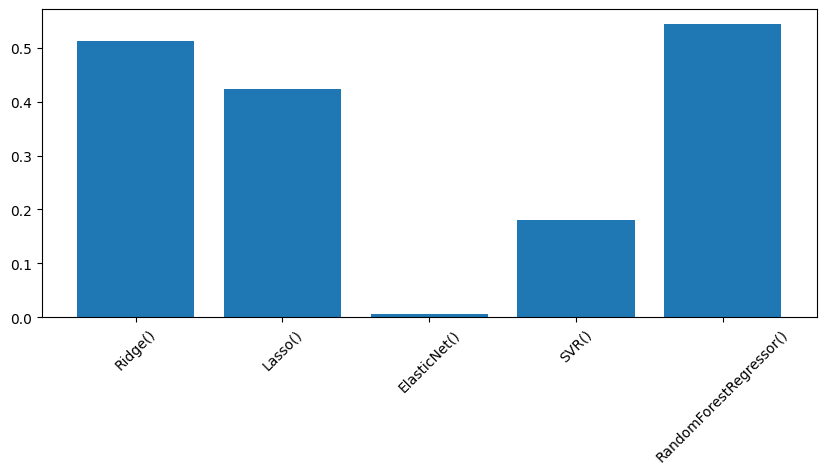

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,4))

plt.bar(range(len(regressors)), model_r2)

plt.xticks(range(len(regressors)), labels = regressors, rotation = 45)
plt.show()